In [1]:
import git
from pathlib import Path
import os
ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
os.chdir(os.path.join(ROOT_DIR, 'anderson-darling'))
from testing_ad import *
os.chdir(os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [16]:
# requires pre-sorted samples
def compute_adstat_from_cdfs(z, subsample_rate=1):
    # z = np.clip(z, eps, 1 - eps)
    n = z.shape[0]
    i = np.arange(1, 2 * n, 2).reshape((n,) + (1,) * (len(z.shape) - 1))
    S = np.mean(i * (np.log(z) + np.log1p(-z[::-1])), axis=0)
    return subsample_rate * (-n - S)

def compare_subsample_stats(rvs, null_cdf, subsampled_size, subsample_rates, M):
    max_samples = 10**8
    eps = 1e-16
    full_sample_stats, subsample_stats = [], []
    for s in subsample_rates:
        print('Working on subsample_rate =', s, end='...\r')
        total_sample_size = s * subsampled_size * M
        batches = -(-total_sample_size // max_samples)
        batch_size, remainder = divmod(M, batches)
        full_sample_stats_col, subsample_stats_col = [], []
        for b in [batch_size] * batches + ([remainder] if remainder else []):
            samples = np.sort(rvs(s * subsampled_size, b), axis=0)
            full_cdfs = null_cdf(samples).clip(eps, 1 - eps)
            full_sample_stats_col.append(compute_adstat_from_cdfs(full_cdfs))
            subsample_cdfs = full_cdfs[::s]
            subsample_stats_col.append(compute_adstat_from_cdfs(subsample_cdfs, s))
        full_sample_stats.append(np.concatenate(full_sample_stats_col))
        subsample_stats.append(np.concatenate(subsample_stats_col))
    print()
    return np.vstack(full_sample_stats), np.vstack(subsample_stats)

def generate_comparison_results(full_sample_stats, subsample_stats, subsample_rates, compute_pvals=True):
    stat_diffs = subsample_stats - full_sample_stats
    results = pd.DataFrame(
        {'stat_ratio': (subsample_stats / full_sample_stats).mean(axis=1),
         'stat_bias': np.mean(stat_diffs, axis=1),
         'stat_rmse': np.sqrt(np.mean(stat_diffs**2, axis=1))},
        index=subsample_rates)
    if compute_pvals:
        print('Computing p-values...', flush=True)
        full_sample_pvals = 1 - ad_asymptotic_cdf(full_sample_stats)
        subsample_pvals = 1 - ad_asymptotic_cdf(subsample_stats)
        pval_diffs = subsample_pvals - full_sample_pvals
        results['pval_ratio'] = (subsample_pvals / full_sample_pvals).mean(axis=1)
        results['pval_bias'] = np.mean(pval_diffs, axis=1)
        results['pval_mae'] = np.mean(np.abs(pval_diffs), axis=1)
    results.index.name = 'subsample_rate'
    return results 

def compare_subsample_results(rvs, null_cdf, subsampled_size, subsample_rates, M, compute_pvals=True):
    return generate_comparison_results(
        *compare_subsample_stats(rvs, null_cdf, subsampled_size, subsample_rates, M),
        subsample_rates, compute_pvals)

def plot_bias_fits(results):
    # bias ~ beta * (subsample_rate - 1)
    data = results.drop(1, errors='ignore')
    x = data.index - 1
    beta_stat = np.dot(x, data['stat_bias']) / np.dot(x, x)
    beta_pval = np.dot(x, data['pval_bias']) / np.dot(x, x)

    stat_preds = beta_stat * (results.index - 1)
    stat_resids = results['stat_bias'] - stat_preds
    pval_preds =  beta_pval * (results.index - 1)
    pval_resids = results['pval_bias'] - pval_preds
    stat_resid_window = np.max(np.abs(stat_resids)) * 1.2
    pval_resid_window = np.max(np.abs(pval_resids)) * 1.2

    fig, axs = plt.subplots(2, 2, sharex=True, figsize=(12, 8))
    ax11, ax12, ax21, ax22 = axs.flatten()

    ax11.plot(results.index, results['stat_bias'], label='Observed')
    ax11.plot(results.index, stat_preds, label=fr'Fit line: $y = {beta_stat:.6f}(x - 1)$')
    ax11.set_ylabel('Bias (subsample – true)')
    ax11.set_title('Subsample rate vs. AD statistic bias')
    ax11.legend()

    ax12.plot(results.index, results['pval_bias'], label='Observed')
    ax12.plot(results.index, beta_pval * (results.index - 1), 
            label=fr'Fit line: $y = {beta_pval:.6f}(x - 1)$')
    ax12.set_title('Subsample rate vs. AD p-value bias')
    ax12.legend()

    ax21.scatter(results.index, stat_resids)
    ax21.axhline(0, ls='--')
    ax21.set_ylim(-stat_resid_window, stat_resid_window)
    ax21.set_xlabel('Subsample rate')
    ax21.set_ylabel('Residual (obs – fit)')

    ax22.scatter(results.index, pval_resids)
    ax22.set_ylim(-pval_resid_window, pval_resid_window)
    ax22.axhline(0, ls='--')
    ax22.set_xlabel('Subsample rate')

    plt.tight_layout()
    plt.show()

def plot_ratio_fit(results):
    # ratio - 1 ~ beta * (subsample_rate - 1)
    data = results.drop(1, errors='ignore')
    x, y = data.index - 1, data['stat_ratio'] - 1
    beta_ratio = np.dot(x, y) / np.dot(x, x)

    ratio_preds = beta_ratio * (results.index - 1) + 1

    plt.plot(results.index, results['stat_ratio'], label='Observed')
    plt.plot(results.index, ratio_preds, label=fr'Fit line: $y - 1 = {beta_ratio:.6f}(x - 1)$')
    plt.xlabel('Subsample rate')
    plt.ylabel('Statistic ratio (subsample / true)')
    plt.title('Subsample rate vs. AD statistic ratio')
    plt.legend()
    plt.show()

In [3]:
results_100 = compare_subsample_results(
    rvs = np.random.rand, # rvs(d1, d2)
    null_cdf = lambda x: x,
    subsampled_size = 100, # size used in most pipelines = 100000
    subsample_rates = np.arange(2, 100, 8),
    M = 10000, # repetitions per subsample rate
)
results_100

Working on subsample_rate = 98...
Computing p-values...


,stat_ratio,stat_bias,stat_rmse,pval_ratio,pval_bias,pval_mae
subsample_rate,,,,,,
2,1.050197,0.033298,0.133508,0.970708,-0.017596,0.047600
10,1.699380,0.455806,0.698037,0.684777,-0.197441,0.228926
18,2.482000,0.955014,1.219270,0.450483,-0.328233,0.340640
26,3.345524,1.512568,1.778310,0.271850,-0.407632,0.411609
34,4.158657,2.060938,2.338939,0.179388,-0.443818,0.445353
42,5.096610,2.645721,2.921886,0.109239,-0.472219,0.472657
50,5.927800,3.222883,3.514066,0.071072,-0.480914,0.481101
58,6.995180,3.856535,4.151233,0.043694,-0.495225,0.495272
66,7.870645,4.458902,4.763691,0.029924,-0.494215,0.494245


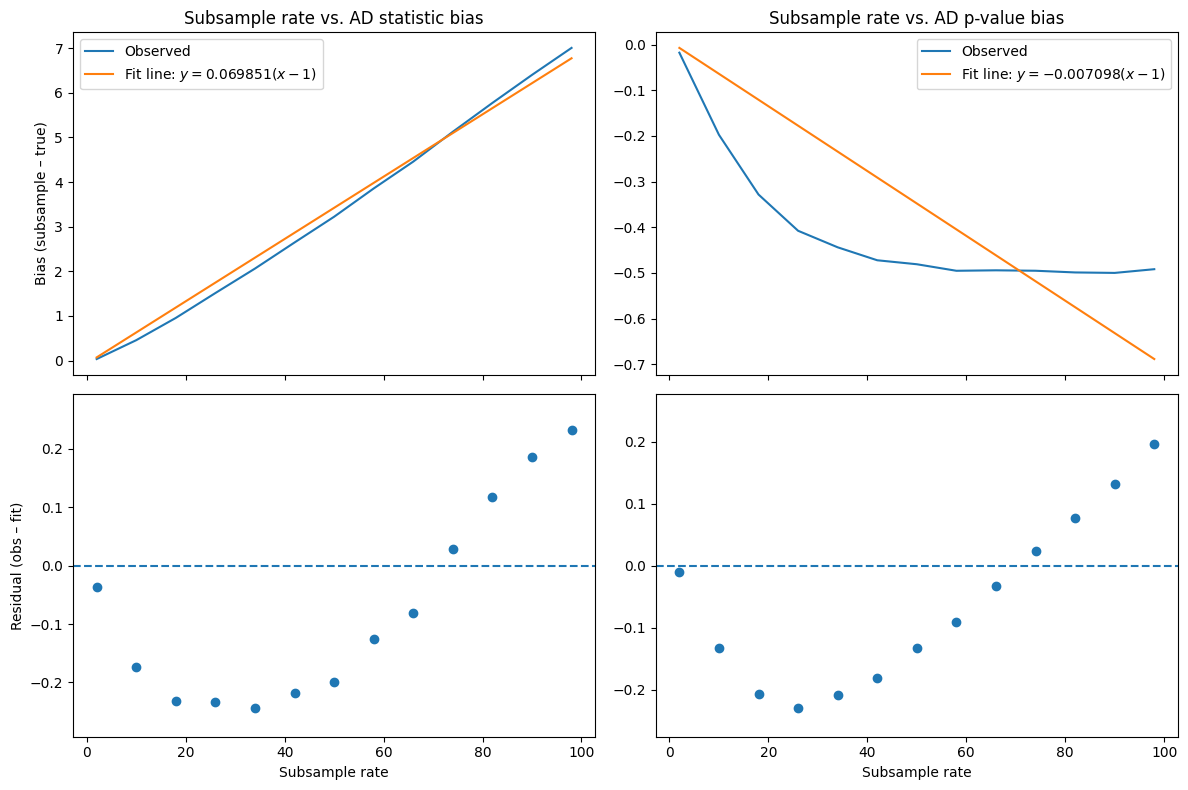

In [4]:
plot_bias_fits(results_100)

In [6]:
results_1000 = compare_subsample_results(
    rvs = np.random.rand, # rvs(d1, d2)
    null_cdf = lambda x: x,
    subsampled_size = 1000, # size used in most pipelines = 100000
    subsample_rates = np.arange(2, 100, 8),
    M = 10000, # repetitions per subsample rate
)
results_1000

Working on subsample_rate = 98...
Computing p-values...


,stat_ratio,stat_bias,stat_rmse,pval_ratio,pval_bias,pval_mae
subsample_rate,,,,,,
2,1.006255,0.003579,0.040754,0.996870,-0.002083,0.014810
10,1.089769,0.058601,0.174341,0.947002,-0.031416,0.063223
18,1.185594,0.118397,0.261089,0.894456,-0.064029,0.094813
26,1.292504,0.189247,0.339968,0.830389,-0.099691,0.125653
34,1.390262,0.253347,0.414421,0.778984,-0.129070,0.152360
42,1.507303,0.331639,0.493620,0.715804,-0.162252,0.180056
50,1.626171,0.403771,0.568610,0.663582,-0.193435,0.207884
58,1.731189,0.471611,0.641397,0.619043,-0.218965,0.230625
66,1.841045,0.549817,0.720140,0.569558,-0.242571,0.251722


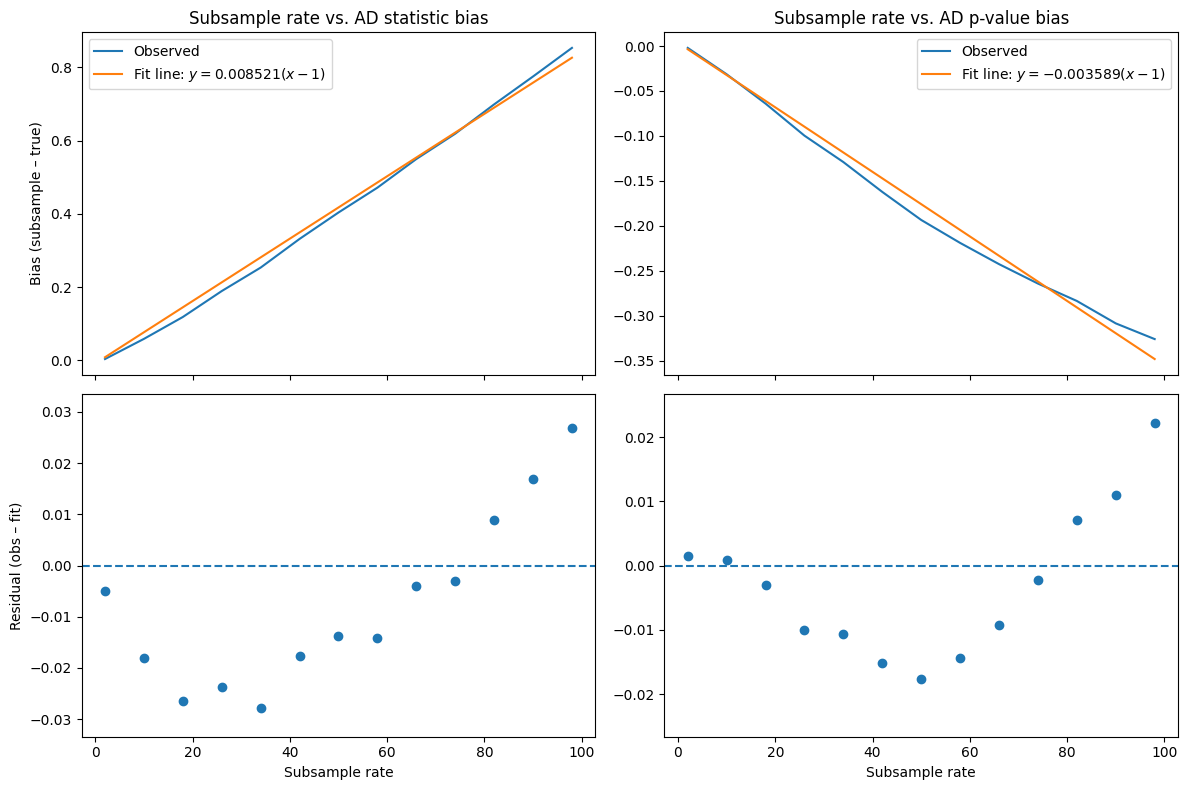

In [7]:
plot_bias_fits(results_1000)

In [8]:
subsample_rates = np.arange(2, 100, 8)
full_sample_stats, subsample_stats = compare_subsample_stats(
    rvs = np.random.rand, # rvs(d1, d2)
    null_cdf = lambda x: x,
    subsampled_size = 10000, # size used in most pipelines = 100000
    subsample_rates = subsample_rates,
    M = 5000 # repetitions per subsample rate
)
results_10000 = generate_comparison_results(
    full_sample_stats, subsample_stats, subsample_rates
)
results_10000

Working on subsample_rate = 98...
Computing p-values...


,stat_ratio,stat_bias,stat_rmse,pval_ratio,pval_bias,pval_mae
subsample_rate,,,,,,
2,1.000817,0.000425,0.013106,0.999622,-0.000272,0.004585
10,1.011150,0.007331,0.052224,0.992648,-0.004054,0.018765
18,1.022074,0.014575,0.074988,0.985611,-0.007919,0.026544
26,1.031808,0.020564,0.091553,0.979848,-0.011623,0.033080
34,1.048626,0.032884,0.106753,0.966267,-0.017552,0.039615
42,1.060230,0.036910,0.118576,0.963152,-0.021748,0.044770
50,1.072485,0.046261,0.133390,0.953587,-0.026020,0.049269
58,1.086564,0.056866,0.145871,0.942113,-0.031564,0.054640
66,1.096309,0.061255,0.158092,0.938782,-0.034977,0.058603


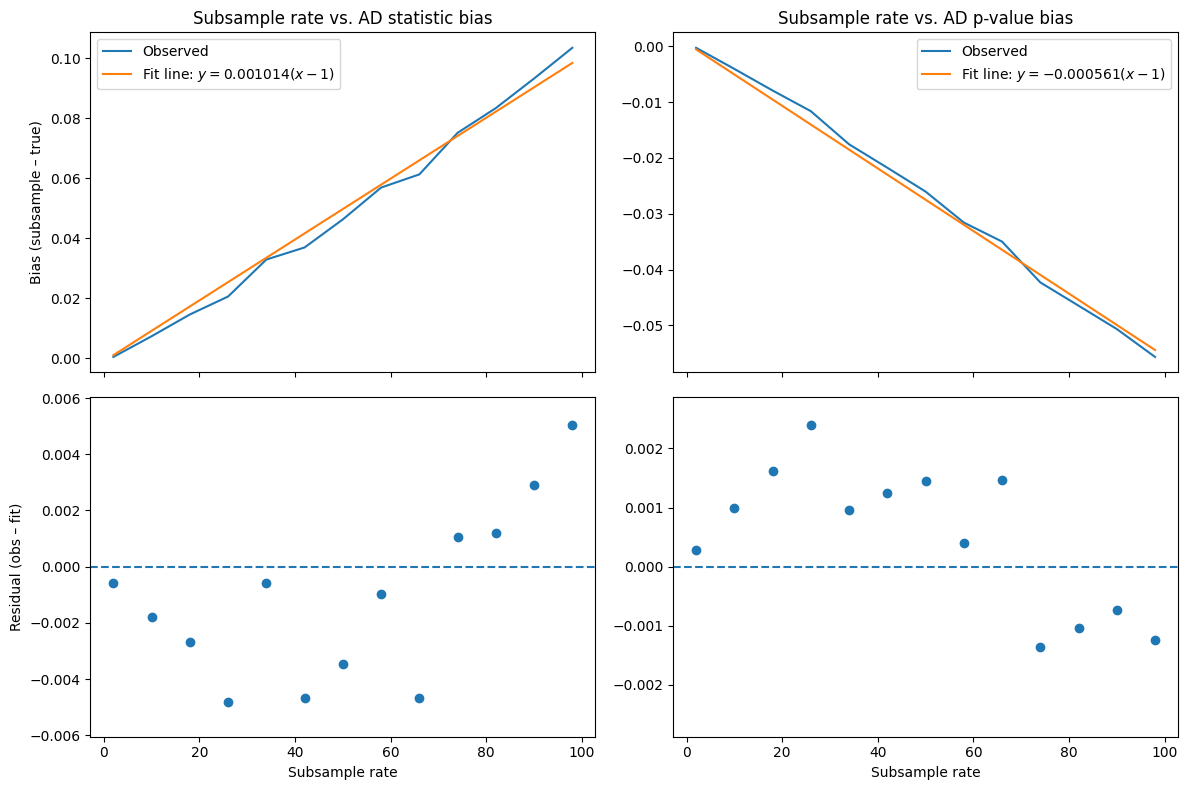

In [9]:
plot_bias_fits(results_10000)

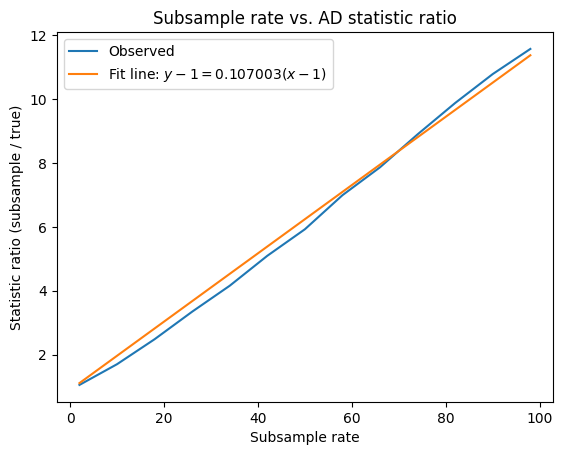

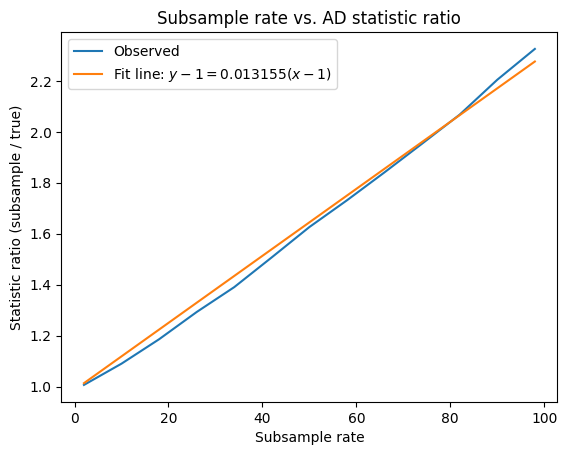

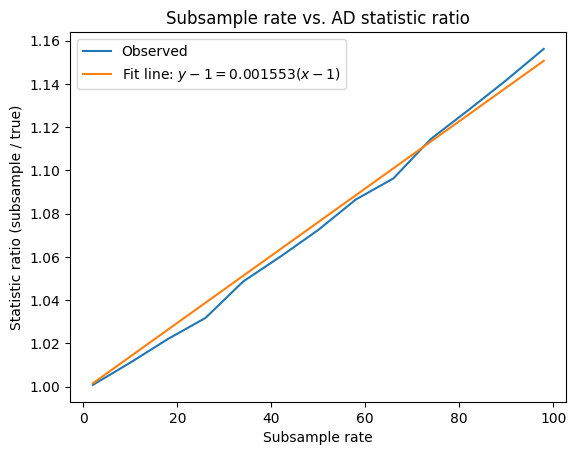

In [10]:
plot_ratio_fit(results_100)
plot_ratio_fit(results_1000)
plot_ratio_fit(results_10000)

Working on subsample_rate = 98...


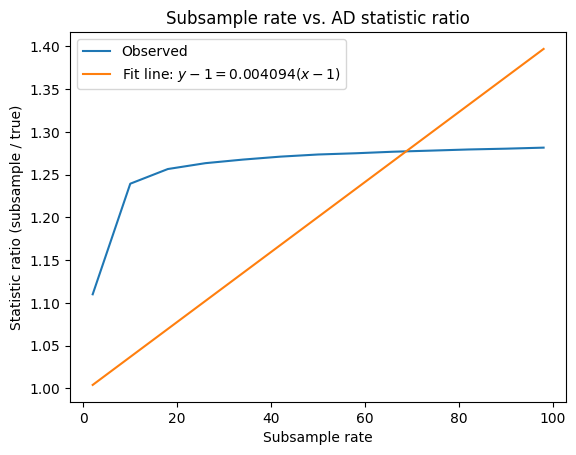

Working on subsample_rate = 98...


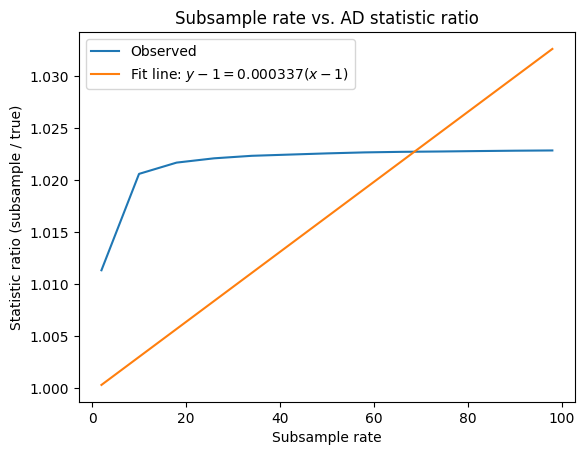

Working on subsample_rate = 98...


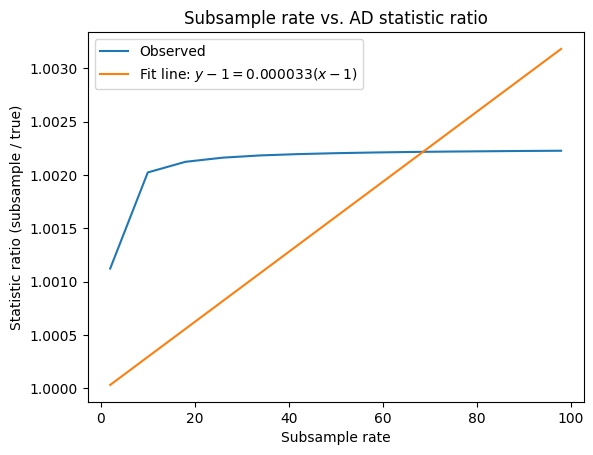

In [17]:
for subsample_size in [100, 1000, 10000]:
    results_misspec = compare_subsample_results(
        rvs = lambda d1, d2: np.random.rand(d1, d2)**1.2,
        null_cdf = lambda x: x,
        subsampled_size = subsample_size,
        subsample_rates = np.arange(2, 100, 8),
        M = 10000,
        compute_pvals=False
    )
    plot_ratio_fit(results_misspec)

In [20]:
# 1376940 -> 100000, ad_fourier_pastis_gray AD pipeline
compare_subsample_results(
    rvs = np.random.rand, # rvs(d1, d2)
    null_cdf = lambda x: x,
    subsampled_size = 100000,
    subsample_rates = [13], 
    M = 5000, # repetitions per subsample rate
)

Working on subsample_rate = 13...
Computing p-values...


,stat_ratio,stat_bias,stat_rmse,pval_ratio,pval_bias,pval_mae
subsample_rate,,,,,,
13,1.002141,0.001436,0.018963,0.998426,-0.000789,0.007024


In [22]:
# 1376940 -> 100000, ad_fourier_pastis_gray AD pipeline
compare_subsample_results(
    rvs = lambda d1, d2: np.random.rand(d1, d2)**1.1,
    null_cdf = lambda x: x,
    subsampled_size = 100000,
    subsample_rates = [13], 
    M = 5000, # repetitions per subsample rate
)

Working on subsample_rate = 13...
Computing p-values...


,stat_ratio,stat_bias,stat_rmse,pval_ratio,pval_bias,pval_mae
subsample_rate,,,,,,
13,1.000395,1.926175,1.926275,1.271526,-1.639089e+276,1.639089e+276


In [23]:
# 1376940 -> 100000, ad_fourier_pastis_gray AD pipeline
compare_subsample_results(
    rvs = lambda d1, d2: np.random.rand(d1, d2)**1.2,
    null_cdf = lambda x: x,
    subsampled_size = 100000,
    subsample_rates = [13], 
    M = 5000, # repetitions per subsample rate
    compute_pvals=False
)

Working on subsample_rate = 13...


,stat_ratio,stat_bias,stat_rmse
subsample_rate,,,
13,1.000207,3.763561,3.763618
